# Task 1 — CollegeMsg Temporal Network

Analisi della rete temporale **CollegeMsg** — messaggi privati su social universitario (UC Irvine).

**Fonte:** https://snap.stanford.edu/data/CollegeMsg.html  
**Dataset file:** `CollegeMsg.txt`

---
## Struttura
1. Setup e import
2. Codice MTM (Motif Transition Model)
3. Codice TMC (Temporal Motif Counting)
4. Caricamento dataset
5. Esecuzione MTM
6. Esecuzione TMC
7. Visualizzazione risultati
8. Null Models (Time Shuffle, Edge Shuffle, Watts-Strogatz)
9. Visualizzazione grafica dei motif


---
## 1. Setup

In [8]:
from __future__ import annotations
import random, os, time, math, gzip, urllib.request
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import networkx as nx

Vertex      = str
Timestamp   = int
Edge        = Tuple[Vertex, Vertex]
Event       = Tuple[Timestamp, Edge]
Motif       = Tuple[Event, ...]
MotifCount  = Dict[str, Tuple[float, List[int]]]
Transition  = Dict[str, List[Tuple[str, float, float]]]
InstanceMap = Dict[tuple, Tuple[int, Set[Vertex]]]

# Cartelle output
OUT_PNG  = 'output_png'
OUT_DATA = 'output_data'
os.makedirs(OUT_PNG,  exist_ok=True)
os.makedirs(OUT_DATA, exist_ok=True)

print('Import OK ✓')
print(f'Output PNG  → {OUT_PNG}/')
print(f'Output data → {OUT_DATA}/')

Import OK ✓
Output PNG  → output_png/
Output data → output_data/


---
## 2. Codice MTM — Motif Transition Model
Traduzione fedele di `src/mtm.cpp` + `src/mtm.hpp` (KDD23-MTM)

In [9]:
def create_events(filename):
    """Legge edge list temporale (u v t), restituisce eventi ordinati + set nodi."""
    events = []; V = set()
    with open(filename, 'r') as fh:
        for line in fh:
            line = line.strip()
            if not line or line[0] in ('%', '#'): continue
            parts = line.split()
            if len(parts) < 3: continue
            u, v, t = parts[0], parts[1], int(float(parts[2]))
            if u != v: V.add(u); V.add(v); events.append((t, (u, v)))
    events.sort()
    events = list(dict.fromkeys(events))
    return events, V

def encode_motif(instance):
    """Mappa i vertici a cifre intere progressive (ordine di prima apparizione)."""
    code = {}; i = 0; result = []
    for (_, (u, v)) in instance:
        if u not in code: code[u] = str(i); i += 1
        result.append(code[u])
        if v not in code: code[v] = str(i); i += 1
        result.append(code[v])
    return ''.join(result)

def get_nodes(events):
    nodes = set()
    for (_, (u, v)) in events: nodes.add(u); nodes.add(v)
    return nodes

def motif_edges(code): return max(int(c) for c in code) - 1

def count_size(events):
    edges = set()
    for (_, (u, v)) in events: edges.add((u, v)); edges.add((v, u))
    return len(edges) // 2

def count_mtp(e, MC, prefixes, N_event, d_c, initial_E):
    """countMTP: processa un evento, aggiorna conteggi motif e prefissi attivi."""
    t_e, (u, v) = e; is_initial = True; new_motifs = []; keep = set()
    for pre_tuple in prefixes:
        pre = list(pre_tuple); t_last = pre[-1][0]
        if (t_e - t_last) > d_c or len(pre) >= N_event: continue
        nodes = get_nodes(pre)
        if u in nodes or v in nodes:
            if t_last != t_e:
                m_new = pre + [e]; new_motifs.append(m_new)
                code_new = encode_motif(m_new)
                if code_new not in MC: MC[code_new] = (0.0, [])
                cnt, times = MC[code_new]
                MC[code_new] = (cnt + 1, times + [t_e - t_last])
                is_initial = False; continue
        keep.add(pre_tuple)
    if is_initial: initial_E.append(e); keep.add((e,))
    for m in new_motifs: keep.add(tuple(m))
    return keep

def count_transition(MC, initial_size):
    """countTransition: costruisce la tabella di transizione."""
    TR = defaultdict(list); new_edge = 0.0
    for code, (c, times) in MC.items():
        code_0 = code[:-2]; code_1 = code[-2:]
        new_edge += motif_edges(code) * c
        lam = (1.0 / (sum(times) / len(times))) if times else 0.0
        TR[code_0].append((code_1, c, lam))
    new_ratio = new_edge / initial_size if initial_size > 0 else 0.0
    for code_0, transitions in list(TR.items()):
        c_sum = sum(t[1] for t in transitions)
        s_count = (initial_size - c_sum) if code_0 == '01' else (MC.get(code_0, (0.0, []))[0] - c_sum)
        TR[code_0].append(('S', s_count, 0.0))
    for code in MC:
        if code not in TR: TR[code] = [('S', 1.0, 0.0)]
    return dict(TR), new_ratio

def randomize_ie(initial_E, V):
    """RandomizeIE: randomizza i nodi degli eventi iniziali preservando la degree sequence."""
    ie_projection = defaultdict(list)
    for (t, e) in initial_E: ie_projection[e].append(t)
    degree_count = Counter()
    for (u, v) in ie_projection: degree_count[u] += 1; degree_count[v] += 1
    degrees = list(degree_count.values())
    nodes_rep = [idx for idx, deg in enumerate(degrees) for _ in range(deg)]
    random.shuffle(nodes_rep)
    graph_nodes = list(V); random.shuffle(graph_nodes)
    randomized = []; idx = 0
    for (_, timestamps) in ie_projection.items():
        for t in timestamps:
            randomized.append((t, (graph_nodes[nodes_rep[idx]], graph_nodes[nodes_rep[idx+1]])))
        idx += 2
    return randomized

def generate_graph(TR, IE, V, Max_event, K, graph_size, new_ratio):
    """generateGraph: genera grafo temporale sintetico con il modello di transizione."""
    out_graph = []
    IE_size = count_size(IE)
    use_existing = ((graph_size - IE_size) / (len(IE) * new_ratio) if len(IE) > 0 and new_ratio > 0 else 0.0)
    AJ = defaultdict(lambda: (set(), set())); node_list = list(V)
    for e in IE:
        t, (u, v) = e; out_graph.append(e)
        AJ[u][1].add(v); AJ[v][0].add(u)
        nodes = [u, v]; code_0 = '01'
        while len(code_0) < 2 * Max_event:
            transitions = TR.get(code_0)
            if not transitions: break
            weights = [max(tr[1], 0.0) for tr in transitions]
            if sum(weights) <= 0: break
            r = random.choices(range(len(transitions)), weights=weights, k=1)[0]
            code_1, lam = transitions[r][0], transitions[r][2]
            if code_1 == 'S': break
            n1, n2 = int(code_1[0]), int(code_1[1])
            if n1 >= len(nodes):
                v_node = nodes[n2]; in_nbrs = list(AJ[v_node][0])
                if random.random() < (1 - use_existing) and in_nbrs: u_new = random.choice(in_nbrs)
                else:
                    cands = [nd for nd in node_list if nd not in nodes]
                    u_new = random.choice(cands) if cands else random.choice(node_list)
                nodes.append(u_new); u_node, v_node = u_new, v_node
            elif n2 >= len(nodes):
                u_node = nodes[n1]; out_nbrs = list(AJ[u_node][1])
                if random.random() < (1 - use_existing) and out_nbrs: v_new = random.choice(out_nbrs)
                else:
                    cands = [nd for nd in node_list if nd not in nodes]
                    v_new = random.choice(cands) if cands else random.choice(node_list)
                nodes.append(v_new); u_node, v_node = u_node, v_new
            else: u_node, v_node = nodes[n1], nodes[n2]
            delta_t = int(random.expovariate(lam)) if lam > 0 else 0
            t += delta_t; out_graph.append((t, (u_node, v_node)))
            AJ[u_node][1].add(v_node); AJ[v_node][0].add(u_node)
            code_0 += code_1
    return out_graph

def run_mtm(input_file, l_max, delta, K, output_file=None, verbose=True):
    """Pipeline MTM completa (equivalente al main() C++)."""
    t0 = time.time()
    if verbose: print(f'Max event: {l_max}  |  Memory: {delta}s  |  K: {K}')
    events, V = create_events(input_file)
    if verbose: print(f'# eventi: {len(events):,}  |  # nodi: {len(V):,}')
    MC = {}; prefixes = set(); initial_E = []
    if verbose: print('Calcolo transizioni...')
    for i, e in enumerate(events):
        if verbose and i % 1000 == 0: print(f'  {i}/{len(events)}', end='\r')
        prefixes = count_mtp(e, MC, prefixes, l_max, delta, initial_E)
    if verbose: print(f'  {len(events)}/{len(events)} ✓')
    TR, new_ratio = count_transition(MC, len(initial_E))
    graph_size = count_size(events); t1 = time.time()
    if verbose: print(f'Transizioni: {len(MC)} tipi di motif  ({t1-t0:.2f}s)')
    RIE = randomize_ie(initial_E, V)
    out_graph = generate_graph(TR, RIE, V, l_max, K, graph_size, new_ratio)
    t2 = time.time()
    if verbose: print(f'Grafo generato: {len(out_graph):,} eventi  |  totale: {t2-t0:.2f}s')
    if output_file:
        with open(output_file, 'w') as fh:
            for (t, (u, v)) in out_graph: fh.write(f'{u} {v} {t}\n')
        if verbose: print(f'Salvato: {output_file}')
    return out_graph

print('MTM completo ✓')


MTM completo ✓


---
## 3. Codice TMC — Temporal Motif Counting
Traduzione fedele di `Temporal_Motifs_Counting/tmc.cpp` + `tmc.hpp`

In [10]:
def count_instance(e, imap, keys, N_event, d_c, consecutive):
    """countInstance: aggiorna l'instance map con il nuovo evento."""
    t_e, (u, v) = e; new_motifs = []; keep = set()
    for key_tuple in keys:
        key = list(key_tuple); t_last = key[-1][0]
        if t_e - t_last > d_c or len(key) >= N_event: continue
        nodes_in_key = imap[key_tuple][1]
        if u in nodes_in_key or v in nodes_in_key:
            motif_key = tuple(key + [e]); new_nodes = nodes_in_key | {u, v}
            new_motifs.append(key + [e])
            prev_cnt = imap.get(key_tuple, (0, set()))[0]
            old_cnt = imap.get(motif_key, (0, set()))[0]
            imap[motif_key] = (old_cnt + prev_cnt, new_nodes)
            if consecutive: continue
        keep.add(key_tuple)
    for m in new_motifs: keep.add(tuple(m))
    singleton = (e,)
    old_cnt, old_nodes = imap.get(singleton, (0, set()))
    imap[singleton] = (old_cnt + 1, old_nodes | {u, v})
    keep.add(singleton)
    return keep

def run_tmc(input_file, max_event, max_memory, consecutive='NO', output_file=None, verbose=True):
    """Pipeline TMC completa (equivalente al main() C++)."""
    t0 = time.time()
    if verbose: print(f'Max event: {max_event}  |  Memory: {max_memory}s  |  Consecutive: {consecutive}')
    events, _ = create_events(input_file)
    if verbose: print(f'# eventi: {len(events):,}')
    imap = {}; keys = set(); cons = (consecutive.upper() == 'YES')
    if verbose: print('Conteggio istanze motif...')
    for i, e in enumerate(events):
        if verbose and i % 1000 == 0: print(f'  {i}/{len(events)}', end='\r')
        keys = count_instance(e, imap, keys, max_event, max_memory, cons)
    if verbose: print(f'  {len(events)}/{len(events)} ✓')
    motif_count = defaultdict(int)
    for key_tuple, (cnt, _) in imap.items():
        if len(key_tuple) < 2: continue
        motif_count[encode_motif(list(key_tuple))] += cnt
    t1 = time.time()
    if verbose: print(f'Trovati {len(motif_count)} tipi di motif  ({t1-t0:.2f}s)')
    if output_file:
        with open(output_file, 'w') as fh:
            for code, cnt in sorted(motif_count.items()): fh.write(f'{code}\t{cnt}\n')
        if verbose: print(f'Salvato: {output_file}')
    return dict(motif_count)

print('TMC completo ✓')


TMC completo ✓


---
## 4. Caricamento dataset — CollegeMsg
File atteso nella stessa cartella: `CollegeMsg.txt`


In [11]:
DATASET_FILE = 'CollegeMsg.txt'

if os.path.exists(DATASET_FILE):
    print(f'File trovato: {DATASET_FILE} ✓')
else:
    print(f'ERRORE: file non trovato: {DATASET_FILE}')
    print(f'Assicurati che il file sia nella stessa cartella del notebook.')
    raise FileNotFoundError(DATASET_FILE)

events_full, V_full = create_events(DATASET_FILE)
t_min = min(e[0] for e in events_full)
t_max = max(e[0] for e in events_full)
print(f'\nDataset CollegeMsg:')
print(f'  # eventi temporali : {len(events_full):,}')
print(f'  # nodi             : {len(V_full):,}')
print(f'  # archi statici    : {count_size(events_full):,}')
print(f'  span temporale     : {(t_max - t_min) // 86400} giorni')
print(f'  periodo            : {time.strftime("%Y-%m-%d", time.gmtime(t_min))} -> {time.strftime("%Y-%m-%d", time.gmtime(t_max))}')


File trovato: CollegeMsg.txt ✓

Dataset CollegeMsg:
  # eventi temporali : 59,798
  # nodi             : 1,899
  # archi statici    : 13,838
  span temporale     : 193 giorni
  periodo            : 2004-04-15 -> 2004-10-26


In [12]:
N_SAMPLE = 5000

SAMPLE_FILE = os.path.join(OUT_DATA, f'collegemsg_sample_{N_SAMPLE}.txt')
sample_events = events_full[:N_SAMPLE]

with open(SAMPLE_FILE, 'w') as fh:
    for (t, (u, v)) in sample_events:
        fh.write(f'{u} {v} {t}\n')

V_sample = {n for (_, (u, v)) in sample_events for n in (u, v)}
print(f'Sottoinsieme salvato: {SAMPLE_FILE}')
print(f'  # eventi : {len(sample_events):,}')
print(f'  # nodi   : {len(V_sample):,}')

Sottoinsieme salvato: output_data/collegemsg_sample_5000.txt
  # eventi : 5,000
  # nodi   : 530


---
## 5. Esecuzione MTM
Parametri: `L_MAX=4`, `DELTA=86400s` (1 giorno), `K=1`


In [13]:
L_MAX = 3
DELTA = 86400   # finestra temporale in secondi
K     = 1

MTM_OUTPUT = f'output_data/CollegeMsg_generated_{N_SAMPLE}_{L_MAX}_{DELTA}.txt'

out_graph = run_mtm(
    input_file  = SAMPLE_FILE,
    l_max       = L_MAX,
    delta       = DELTA,
    K           = K,
    output_file = MTM_OUTPUT
)


Max event: 3  |  Memory: 86400s  |  K: 1
# eventi: 5,000  |  # nodi: 530
Calcolo transizioni...
  5000/5000 ✓
Transizioni: 60 tipi di motif  (0.04s)
Grafo generato: 5,457 eventi  |  totale: 0.05s
Salvato: output_data/CollegeMsg_generated_5000_3_86400.txt


---
## 6. Esecuzione TMC


In [14]:
TMC_OUTPUT = f'output_data/CollegeMsg_motifs_{N_SAMPLE}_{L_MAX}_{DELTA}.txt'

motif_results = run_tmc(
    input_file  = SAMPLE_FILE,
    max_event   = L_MAX,
    max_memory  = DELTA,
    consecutive = 'NO',
    output_file = TMC_OUTPUT
)


Max event: 3  |  Memory: 86400s  |  Consecutive: NO
# eventi: 5,000
Conteggio istanze motif...
  5000/5000 ✓
Trovati 66 tipi di motif  (243.65s)
Salvato: output_data/CollegeMsg_motifs_5000_3_86400.txt


---
## 7. Visualizzazione risultati MTM + TMC


In [15]:
# 7a. Tabella top-20 motif
df_motifs = pd.DataFrame(
    sorted(motif_results.items(), key=lambda x: -x[1]),
    columns=['motif_code', 'count']
)
df_motifs['n_eventi'] = df_motifs['motif_code'].apply(lambda c: len(c) // 2)
print(f'Totale tipi di motif trovati: {len(df_motifs):,}')
df_motifs.head(20)


Totale tipi di motif trovati: 66


,motif_code,count,n_eventi
0,010203,1115188,3
1,012131,793677,3
2,012123,658134,3
3,010232,565256,3
4,012103,492873,3
5,010231,447307,3
6,012030,409345,3
7,012113,385400,3
8,012132,335212,3
9,011231,323888,3


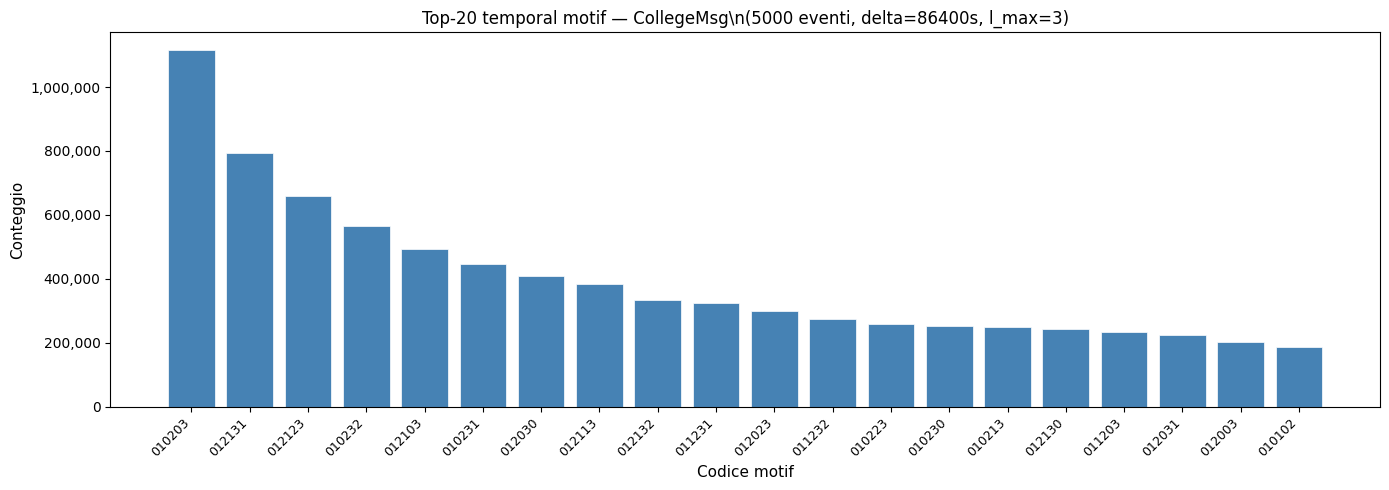

In [16]:
# 7b. Bar chart top-20
top20 = df_motifs.head(20)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(top20)), top20['count'], color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(top20)))
ax.set_xticklabels(top20['motif_code'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Codice motif', fontsize=11)
ax.set_ylabel('Conteggio', fontsize=11)
ax.set_title(f'Top-20 temporal motif — CollegeMsg\\n({N_SAMPLE} eventi, delta={DELTA}s, l_max={L_MAX})', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'output_png/snap_motif_top20.png', dpi=150, bbox_inches='tight')
plt.show()


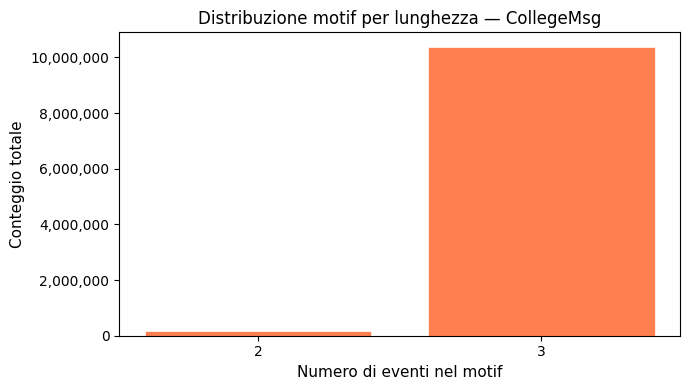

In [17]:
# 7c. Distribuzione per lunghezza
by_len = df_motifs.groupby('n_eventi')['count'].sum().reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_len['n_eventi'], by_len['count'], color='coral', edgecolor='white', linewidth=0.5)
ax.set_xlabel('Numero di eventi nel motif', fontsize=11)
ax.set_ylabel('Conteggio totale', fontsize=11)
ax.set_title(f'Distribuzione motif per lunghezza — CollegeMsg', fontsize=12)
ax.set_xticks(by_len['n_eventi'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'output_png/snap_motif_by_length.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# 7d. Confronto statistiche originale vs generato
gen_events, _ = create_events(MTM_OUTPUT)
gen_nodes_set = {n for (_, (u, v)) in gen_events for n in (u, v)}
df_stats = pd.DataFrame({
    'Metrica'        : ['# eventi', '# archi unici', '# nodi'],
    'Originale'      : [len(sample_events), count_size(sample_events), len(V_sample)],
    'Generato (MTM)' : [len(gen_events), count_size(gen_events), len(gen_nodes_set)],
}).set_index('Metrica')
df_stats['Rapporto'] = (df_stats['Generato (MTM)'] / df_stats['Originale']).round(3)
print('Confronto originale vs generato:')
df_stats


Confronto originale vs generato:


,Originale,Generato (MTM),Rapporto
Metrica,,,
# eventi,5000,5419,1.084
# archi unici,1695,1567,0.924
# nodi,530,503,0.949


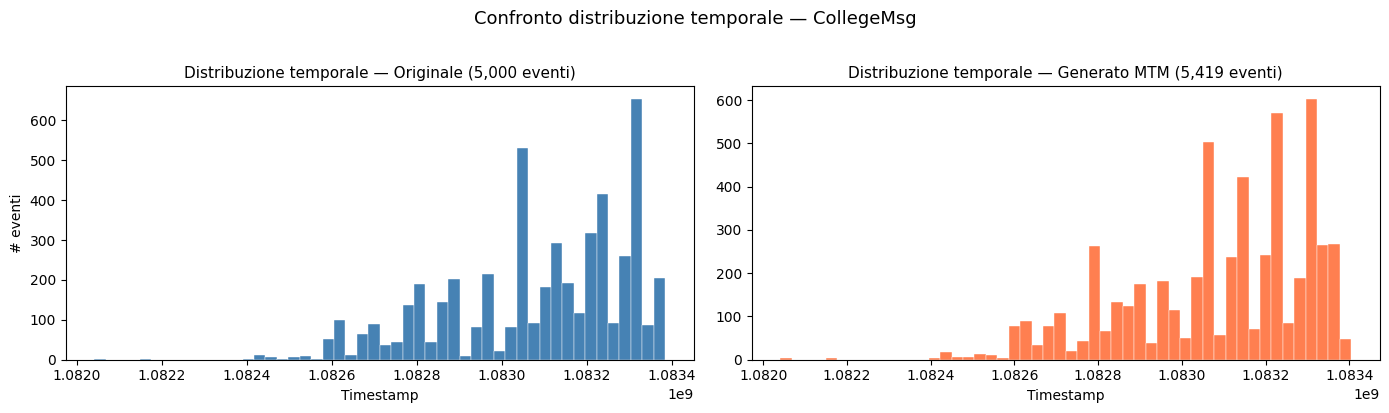

In [19]:
# 7e. Distribuzione temporale
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist([t for (t, _) in sample_events], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Distribuzione temporale — Originale ({len(sample_events):,} eventi)', fontsize=11)
axes[0].set_xlabel('Timestamp'); axes[0].set_ylabel('# eventi')
axes[1].hist([t for (t, _) in gen_events], bins=50, color='coral', edgecolor='white', linewidth=0.3)
axes[1].set_title(f'Distribuzione temporale — Generato MTM ({len(gen_events):,} eventi)', fontsize=11)
axes[1].set_xlabel('Timestamp')
plt.suptitle('Confronto distribuzione temporale — CollegeMsg', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'output_png/snap_temporal_dist.png', dpi=150, bbox_inches='tight')
plt.show()


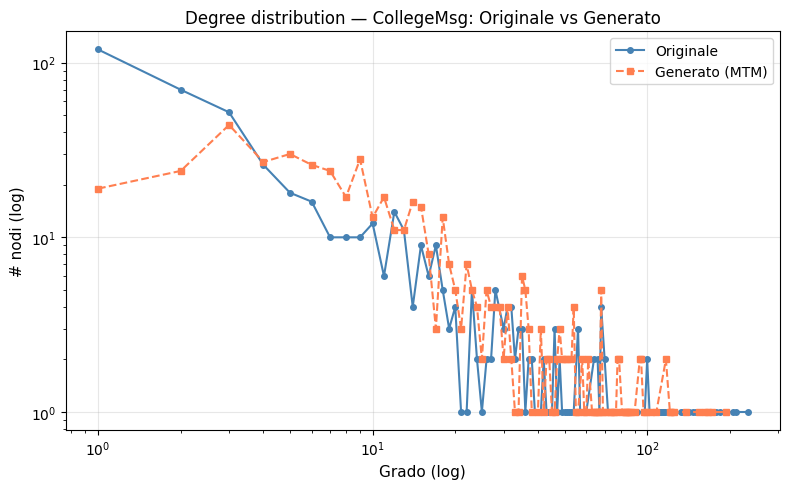

In [20]:
# 7f. Degree distribution
def degree_dist(events):
    deg = Counter()
    for (_, (u, v)) in events: deg[u] += 1; deg[v] += 1
    return sorted(Counter(deg.values()).items())

orig_deg = degree_dist(sample_events)
gen_deg  = degree_dist(gen_events)
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog([d for d, _ in orig_deg], [c for _, c in orig_deg], 'o-', color='steelblue', markersize=4, label='Originale')
ax.loglog([d for d, _ in gen_deg],  [c for _, c in gen_deg],  's--', color='coral', markersize=4, label='Generato (MTM)')
ax.set_xlabel('Grado (log)', fontsize=11); ax.set_ylabel('# nodi (log)', fontsize=11)
ax.set_title('Degree distribution — CollegeMsg: Originale vs Generato', fontsize=12)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'output_png/snap_degree_dist.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Null Models — Randomizzazioni

| # | Nome | Cosa randomizza | Cosa preserva |
|---|------|----------------|---------------|
| 1 | **Time Shuffle** | Timestamp rimescolati | Struttura archi |
| 2 | **Edge Shuffle** | Archi rimescolati (configuration model) | Timestamp + degree sequence |
| 3 | **Watts-Strogatz** | Struttura intera (small-world) | # nodi, distribuzione temporale |


In [21]:
def time_shuffle(events, seed=42):
    """Rimescola i timestamp. Preserva struttura, distrugge correlazioni temporali."""
    rnd = random.Random(seed)
    edges = [e[1] for e in events]; timestamps = [e[0] for e in events]
    rnd.shuffle(timestamps)
    return sorted(zip(timestamps, edges))

def edge_shuffle(events, V, seed=42):
    """Rimescola gli archi preservando degree sequence e timestamp."""
    rnd = random.Random(seed)
    degree_seq = []
    for (_, (u, v)) in events: degree_seq.append(u); degree_seq.append(v)
    rnd.shuffle(degree_seq)
    timestamps = [e[0] for e in events]; new_events = []
    for i, t in enumerate(timestamps):
        u_new = degree_seq[2*i]; v_new = degree_seq[2*i+1]
        if u_new == v_new: v_new = rnd.choice([n for n in list(V) if n != u_new])
        new_events.append((t, (u_new, v_new)))
    return sorted(new_events)

def strogatz_shuffle(events, V, k_neighbors=4, p_rewire=0.1, seed=42):
    """Genera rete Watts-Strogatz con timestamp dalla distribuzione reale."""
    rnd = random.Random(seed)
    nodes = sorted(list(V)); n = len(nodes)
    k = min(k_neighbors, n-1)
    if k % 2 != 0: k -= 1
    half_k = k // 2
    ws_edges = set()
    for i in range(n):
        for j in range(1, half_k+1):
            nb = (i+j) % n; ws_edges.add((min(i,nb), max(i,nb)))
    ws_edges = list(ws_edges); rewired = set(); final_edges = []
    for (i, j) in ws_edges:
        if rnd.random() < p_rewire:
            attempts = 0
            while attempts < 20:
                new_j = rnd.randint(0, n-1); e_new = (min(i,new_j), max(i,new_j))
                if new_j != i and e_new not in rewired:
                    rewired.add(e_new); final_edges.append((nodes[i], nodes[new_j])); break
                attempts += 1
            else: final_edges.append((nodes[i], nodes[j]))
        else: final_edges.append((nodes[i], nodes[j]))
    real_times = sorted([e[0] for e in events]); n_events = len(events)
    ws_sampled = [final_edges[i % len(final_edges)] for i in range(n_events)]
    sampled_times = sorted(rnd.choices(real_times, k=n_events))
    return sorted([(t, (u, v)) for t, (u, v) in zip(sampled_times, ws_sampled) if u != v])

print('Null models definiti ✓')


Null models definiti ✓


In [22]:
# Genera i file dei null model
print('Generazione null models...')
ts_events = time_shuffle(sample_events)
TS_FILE = f'output_data/snap_null_time_shuffle_{N_SAMPLE}.txt'
with open(TS_FILE, 'w') as fh:
    for (t, (u, v)) in ts_events: fh.write(f'{u} {v} {t}\n')
print(f'  Time Shuffle   -> {len(ts_events):,} eventi')

es_events = edge_shuffle(sample_events, V_sample)
ES_FILE = f'output_data/snap_null_edge_shuffle_{N_SAMPLE}.txt'
with open(ES_FILE, 'w') as fh:
    for (t, (u, v)) in es_events: fh.write(f'{u} {v} {t}\n')
print(f'  Edge Shuffle   -> {len(es_events):,} eventi')

ws_events = strogatz_shuffle(sample_events, V_sample)
WS_FILE = f'output_data/snap_null_strogatz_{N_SAMPLE}.txt'
with open(WS_FILE, 'w') as fh:
    for (t, (u, v)) in ws_events: fh.write(f'{u} {v} {t}\n')
print(f'  Watts-Strogatz -> {len(ws_events):,} eventi')
print('Null models generati ✓')


Generazione null models...
  Time Shuffle   -> 5,000 eventi
  Edge Shuffle   -> 5,000 eventi
  Watts-Strogatz -> 5,000 eventi
Null models generati ✓


In [23]:
# TMC sui null model
print('=== TMC su Time Shuffle ===')
motifs_ts = run_tmc(TS_FILE, max_event=L_MAX, max_memory=DELTA, consecutive='NO')
print('\n=== TMC su Edge Shuffle ===')
motifs_es = run_tmc(ES_FILE, max_event=L_MAX, max_memory=DELTA, consecutive='NO')
print('\n=== TMC su Watts-Strogatz ===')
motifs_ws = run_tmc(WS_FILE, max_event=L_MAX, max_memory=DELTA, consecutive='NO')


=== TMC su Time Shuffle ===
Max event: 3  |  Memory: 86400s  |  Consecutive: NO
# eventi: 5,000
Conteggio istanze motif...
  5000/5000 ✓
Trovati 66 tipi di motif  (42.35s)

=== TMC su Edge Shuffle ===
Max event: 3  |  Memory: 86400s  |  Consecutive: NO
# eventi: 5,000
Conteggio istanze motif...
  5000/5000 ✓
Trovati 66 tipi di motif  (102.13s)

=== TMC su Watts-Strogatz ===
Max event: 3  |  Memory: 86400s  |  Consecutive: NO
# eventi: 5,000
Conteggio istanze motif...
  5000/5000 ✓
Trovati 60 tipi di motif  (3.89s)


In [24]:
# Tabella confronto con enrichment score
all_codes = sorted(
    set(motif_results) | set(motifs_ts) | set(motifs_es) | set(motifs_ws),
    key=lambda c: -motif_results.get(c, 0)
)[:30]
rows = []
for code in all_codes:
    real = motif_results.get(code, 0)
    ts = motifs_ts.get(code, 0); es = motifs_es.get(code, 0); ws = motifs_ws.get(code, 0)
    avg_null = (ts + es + ws) / 3 if (ts + es + ws) > 0 else 1
    rows.append({'motif_code': code, 'n_eventi': len(code)//2, 'Reale': real,
                 'Time Shuffle': ts, 'Edge Shuffle': es, 'Strogatz': ws,
                 'Enrichment': round(real / avg_null, 2)})
df_compare = pd.DataFrame(rows).set_index('motif_code')
print('Top-30 motif: rete reale vs null models')
df_compare.sort_values('Enrichment', ascending=False)


Top-30 motif: rete reale vs null models


,n_eventi,Reale,Time Shuffle,Edge Shuffle,Strogatz,Enrichment
motif_code,,,,,,
010121,3,183611,26426,1748,2,19.55
012121,3,177708,27167,1728,76,18.40
010112,3,88194,12685,1734,0,18.35
012020,3,89852,14454,1838,127,16.42
010102,3,185705,33232,1637,4,15.98
010202,3,150223,33890,1713,53,12.64
012123,3,658134,178394,126609,1393,6.44
012131,3,793677,198557,215677,1277,5.73
010232,3,565256,184984,127959,1856,5.39


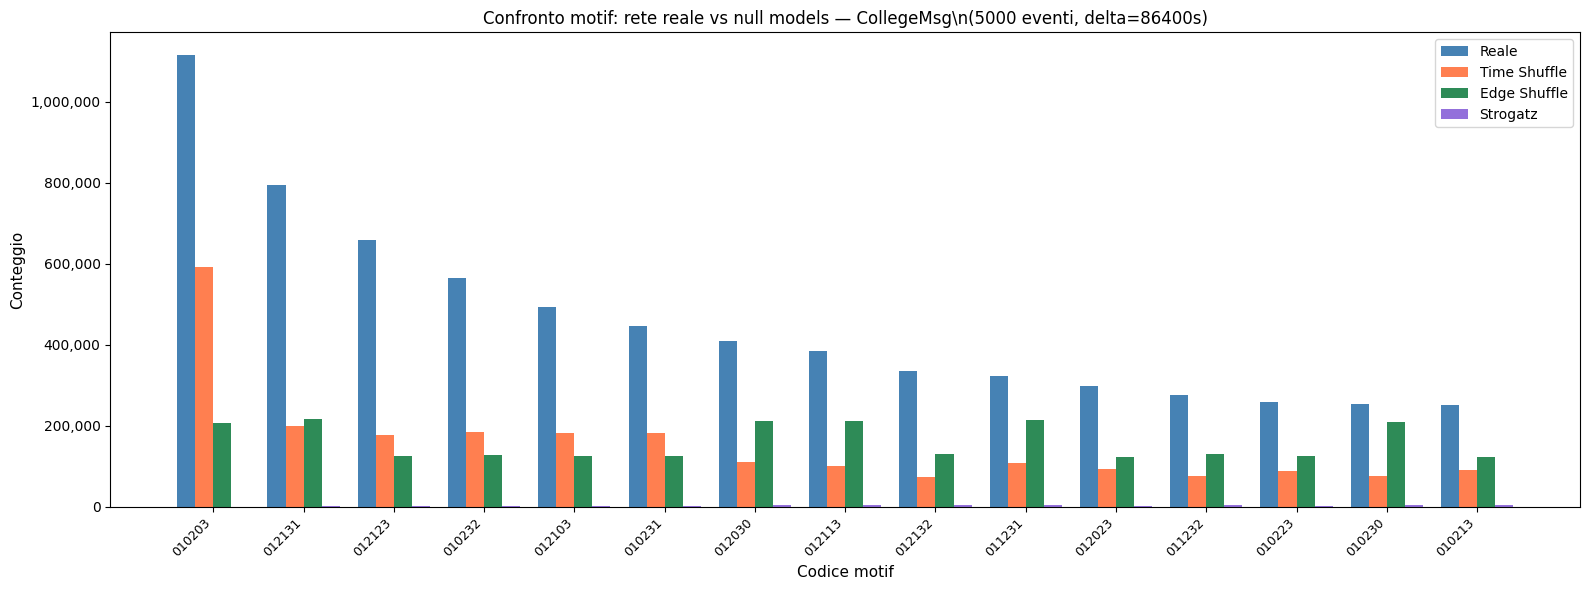

In [25]:
# Bar chart confronto top-15
top15 = df_compare.head(15).reset_index()
x = np.arange(len(top15)); w = 0.2
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x-1.5*w, top15['Reale'],        width=w, label='Reale',        color='steelblue')
ax.bar(x-0.5*w, top15['Time Shuffle'], width=w, label='Time Shuffle', color='coral')
ax.bar(x+0.5*w, top15['Edge Shuffle'], width=w, label='Edge Shuffle', color='seagreen')
ax.bar(x+1.5*w, top15['Strogatz'],     width=w, label='Strogatz',     color='mediumpurple')
ax.set_xticks(x); ax.set_xticklabels(top15['motif_code'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Codice motif', fontsize=11); ax.set_ylabel('Conteggio', fontsize=11)
ax.set_title(f'Confronto motif: rete reale vs null models — CollegeMsg\\n({N_SAMPLE} eventi, delta={DELTA}s)', fontsize=12)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'output_png/snap_null_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


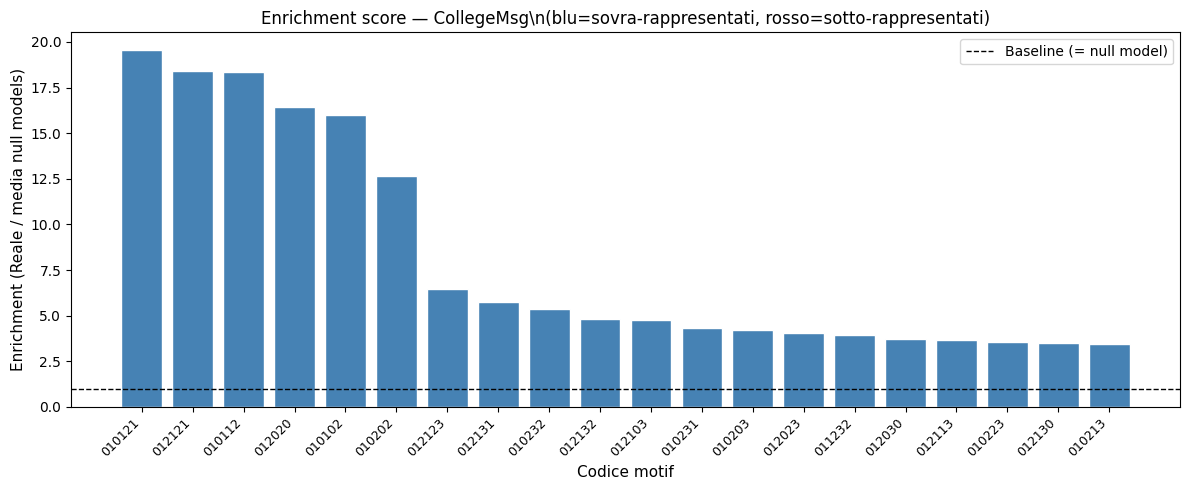

In [26]:
# Enrichment score
df_enrich = df_compare[df_compare['Reale'] > 0].sort_values('Enrichment', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['steelblue' if e >= 1 else 'coral' for e in df_enrich['Enrichment']]
ax.bar(range(len(df_enrich)), df_enrich['Enrichment'], color=colors, edgecolor='white')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='Baseline (= null model)')
ax.set_xticks(range(len(df_enrich)))
ax.set_xticklabels(df_enrich.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Codice motif', fontsize=11)
ax.set_ylabel('Enrichment (Reale / media null models)', fontsize=11)
ax.set_title('Enrichment score — CollegeMsg\\n(blu=sovra-rappresentati, rosso=sotto-rappresentati)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f'output_png/snap_enrichment.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 9. Visualizzazione grafica dei motif

Ogni codice motif viene tradotto nel suo grafo:
- **Cifre** = nodi (0,1,2,3... in ordine di prima apparizione)
- **Coppie di caratteri** = archi diretti (es. `01` = arco 0→1)
- **Colore freccia** = ordine temporale (chiaro=primo, scuro=ultimo)
- **Label t0,t1,t2,t3** = indice temporale dell'arco

### Come funziona `encode_motif()`?
```
eventi: (A->B, t=1), (A->C, t=2), (B->D, t=3)
         A=0, B=1      C=2           D=3
codice:   01    02    13  ->  '010213'
```
Due istanze hanno lo stesso codice se e solo se sono strutturalmente isomorfe.


In [27]:
def parse_motif_code(code):
    """Codice stringa -> lista archi (t, u, v). Ogni coppia di char = un arco."""
    if len(code) % 2 != 0: raise ValueError(f'Codice dispari: {code}')
    return [(i//2, int(code[i]), int(code[i+1])) for i in range(0, len(code), 2)]

def motif_description(code):
    edges = parse_motif_code(code)
    nodes = sorted(set(n for (_, u, v) in edges for n in (u, v)))
    return f"{len(edges)} eventi, {len(nodes)} nodi: " + ', '.join(f'{u}->{v}' for (_, u, v) in edges)

def get_layout(nodes, edges):
    deg = defaultdict(int)
    for (_, u, v) in edges: deg[u] += 1; deg[v] += 1
    max_deg = max(deg.values()); hubs = [nd for nd, d in deg.items() if d == max_deg]
    if max_deg >= 3 and len(hubs) == 1:
        hub = hubs[0]; others = [nd for nd in nodes if nd != hub]
        pos = {hub: (0.0, 0.0)}
        for i, nd in enumerate(others):
            angle = 2*math.pi*i/len(others)
            pos[nd] = (math.cos(angle)*1.2, math.sin(angle)*1.2)
    elif len(nodes) == 2:
        pos = {nodes[0]: (-0.6, 0.0), nodes[1]: (0.6, 0.0)}
    else:
        G_tmp = nx.DiGraph()
        G_tmp.add_nodes_from(nodes)
        G_tmp.add_edges_from([(u, v) for (_, u, v) in edges])
        pos = nx.spring_layout(G_tmp, seed=42, k=1.8)
    return pos

def draw_motif(code, ax, count=None, show_desc=True):
    edges = parse_motif_code(code); n_edges = len(edges)
    nodes = sorted(set(n for (_, u, v) in edges for n in (u, v)))
    pos = get_layout(nodes, edges); cmap = plt.cm.Blues
    G = nx.MultiDiGraph(); G.add_nodes_from(nodes)
    for (_, u, v) in edges: G.add_edge(u, v)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1000,
                           node_color='#2E6DA4', edgecolors='#1a1a2e', linewidths=2)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={nd: str(nd) for nd in nodes},
                            font_color='white', font_size=13, font_weight='bold')
    edge_drawn = defaultdict(int)
    for t, u, v in edges:
        color = cmap(0.35 + 0.55*(t/max(n_edges-1, 1)))
        key = (u, v); opp = (v, u)
        rad = 0.0
        if edge_drawn[key] > 0: rad = 0.25*edge_drawn[key]
        elif edge_drawn[opp] > 0: rad = 0.2
        edge_drawn[key] += 1
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)],
                               edge_color=[color], width=2.8, arrows=True,
                               arrowsize=28, arrowstyle='-|>',
                               connectionstyle=f'arc3,rad={rad}',
                               min_source_margin=24, min_target_margin=24)
        if u != v:
            x = (pos[u][0]+pos[v][0])/2; y = (pos[u][1]+pos[v][1])/2
            dx = pos[v][0]-pos[u][0]; dy = pos[v][1]-pos[u][1]
            norm = (dx**2+dy**2)**0.5+1e-9; off = 0.14+abs(rad)*0.6
            x += -dy/norm*off; y += dx/norm*off
            ax.text(x, y, f't{t}', fontsize=9, ha='center', va='center',
                    color='#222222', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                              edgecolor=color, linewidth=1.8, alpha=0.9))
    title = f'Codice: {code}'
    if count is not None: title += f'   (n={count:,})'
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)
    if show_desc:
        ax.text(0.5, -0.08, motif_description(code), transform=ax.transAxes,
                ha='center', va='top', fontsize=8, color='#555555', style='italic')
    ax.axis('off')

def plot_motif_gallery(motif_dict, top_n=12, ncols=4, title='Top motif', save_path=None):
    from matplotlib.lines import Line2D
    sorted_motifs = sorted(motif_dict.items(), key=lambda x: -x[1])[:top_n]
    nrows = math.ceil(len(sorted_motifs)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*4.2))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, (code, count) in enumerate(sorted_motifs): draw_motif(code, axes[i], count=count)
    for j in range(len(sorted_motifs), len(axes)): axes[j].axis('off')
    cmap = plt.cm.Blues
    legend_elements = [
        Line2D([0],[0], color=cmap(0.38), lw=3, label='t0 - primo arco'),
        Line2D([0],[0], color=cmap(0.57), lw=3, label='t1 - secondo arco'),
        Line2D([0],[0], color=cmap(0.75), lw=3, label='t2 - terzo arco'),
        Line2D([0],[0], color=cmap(0.92), lw=3, label='t3 - quarto arco'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
               title='Ordine temporale degli archi', title_fontsize=11,
               bbox_to_anchor=(0.5, 0.0), framealpha=0.9)
    plt.suptitle(title+'\n(cifre=nodi, frecce=archi diretti, t0..t3=ordine temporale)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f'Salvato: {save_path}')
    plt.show()

print('Funzioni visualizzazione ✓')

# Test
for code in ['0102', '010203', '01020304', '01101213']:
    print(f'  {code:14s} -> {motif_description(code)}')


Funzioni visualizzazione ✓
  0102           -> 2 eventi, 3 nodi: 0->1, 0->2
  010203         -> 3 eventi, 4 nodi: 0->1, 0->2, 0->3
  01020304       -> 4 eventi, 5 nodi: 0->1, 0->2, 0->3, 0->4
  01101213       -> 4 eventi, 4 nodi: 0->1, 1->0, 1->2, 1->3


Salvato: output_png/snap_motif_gallery_real.png


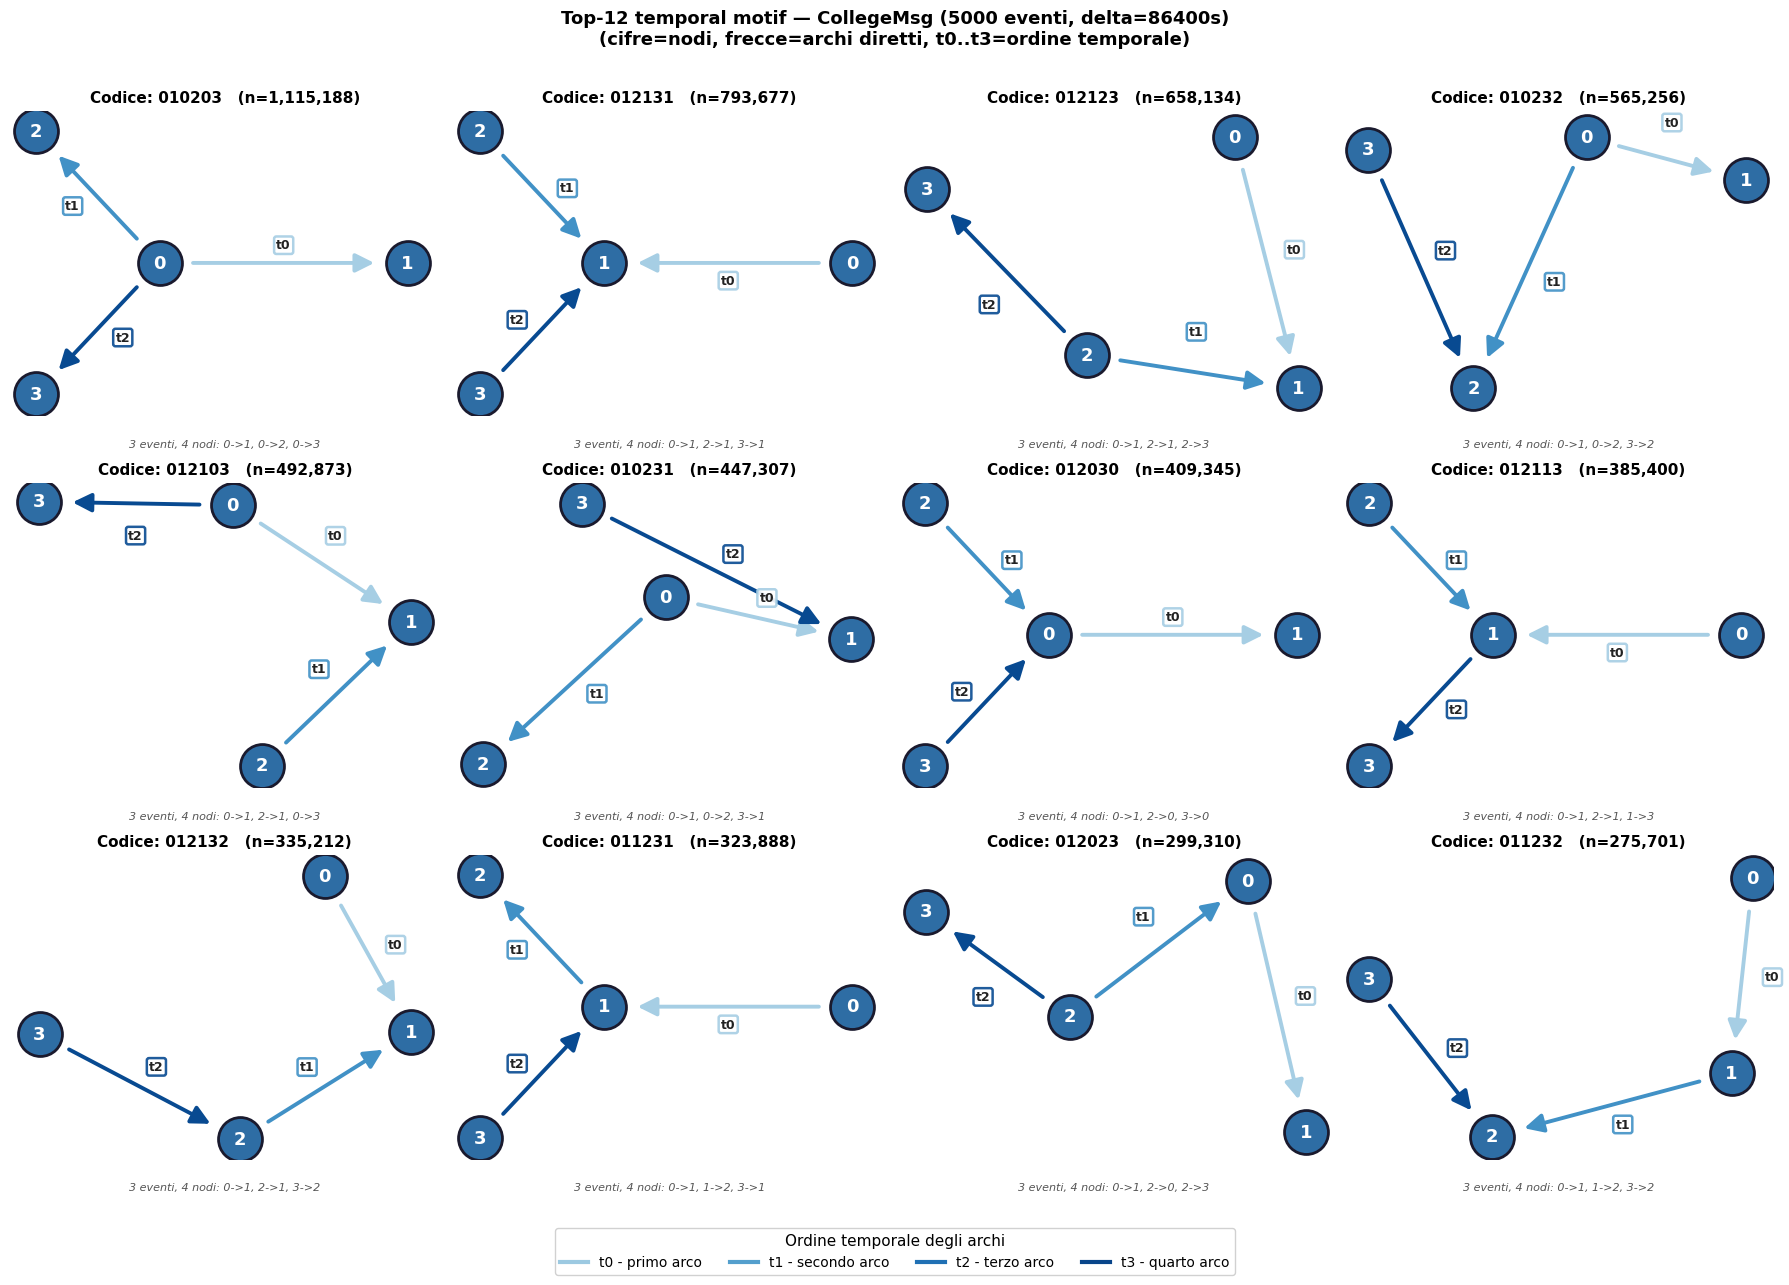

In [28]:
# 9a. Gallery top-12 motif della rete reale
plot_motif_gallery(
    motif_results, top_n=12, ncols=4,
    title=f'Top-12 temporal motif — CollegeMsg ({N_SAMPLE} eventi, delta={DELTA}s)',
    save_path=f'output_png/snap_motif_gallery_real.png'
)


Salvato: output_png/snap_motif_gallery_enriched.png


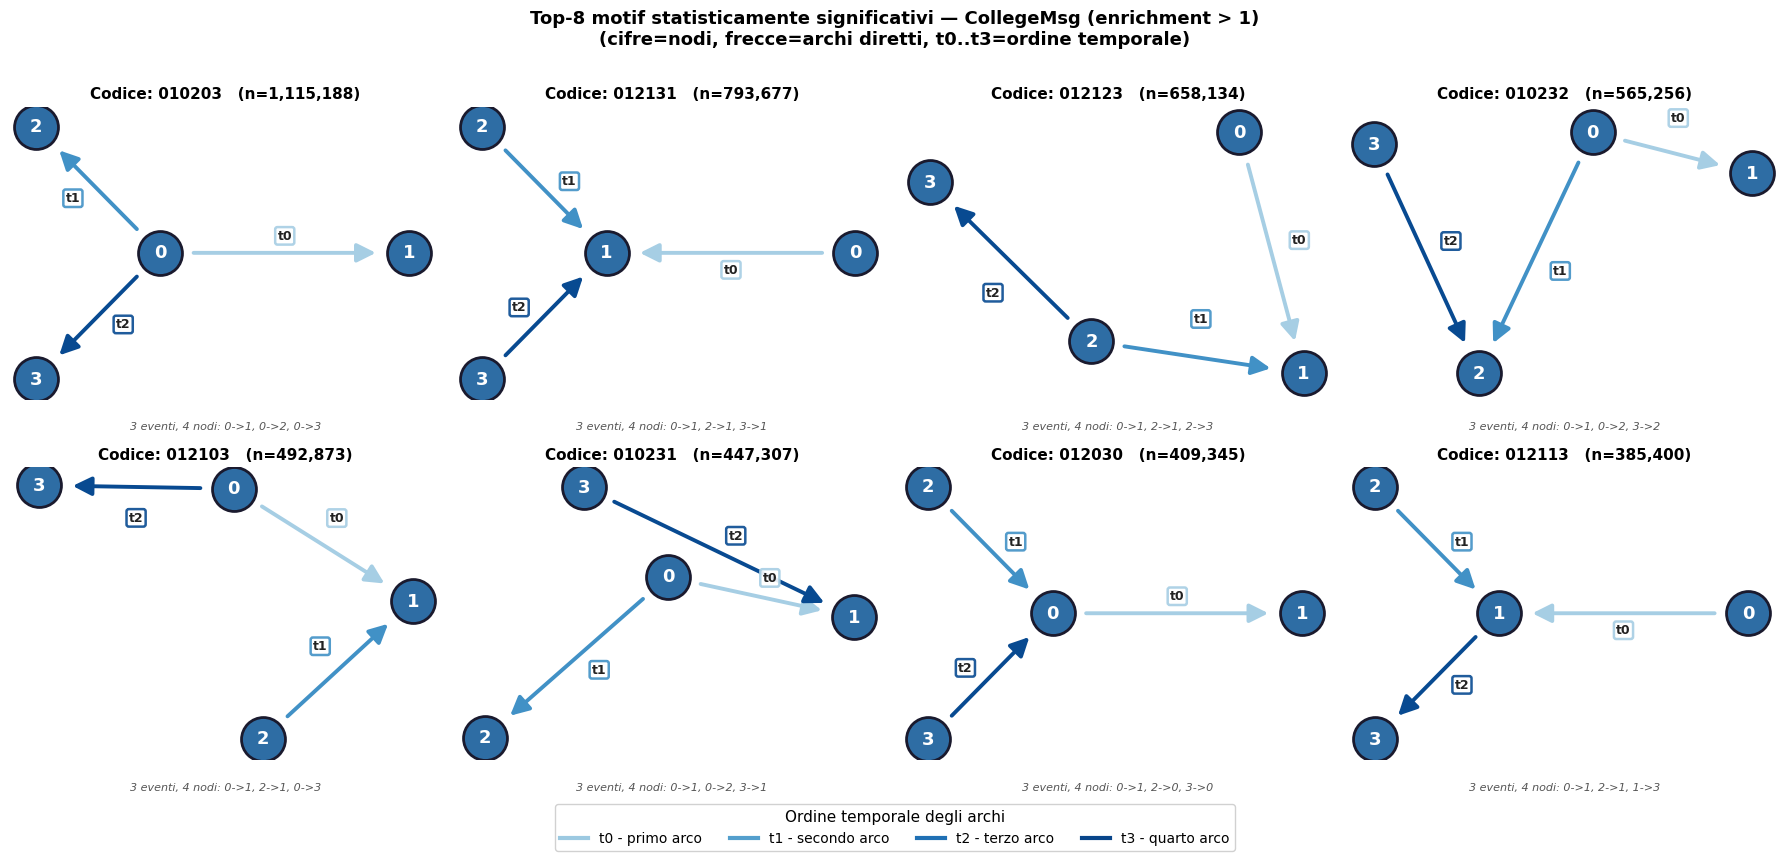

In [29]:
# 9b. Gallery top-8 motif piu significativi (enrichment > 1)
enriched = {code: motif_results[code] for code, row in df_compare.iterrows()
            if row['Enrichment'] > 1.0 and code in motif_results}
enriched_sorted = dict(sorted(enriched.items(), key=lambda x: -df_compare.loc[x[0], 'Enrichment']))
plot_motif_gallery(
    enriched_sorted, top_n=8, ncols=4,
    title='Top-8 motif statisticamente significativi — CollegeMsg (enrichment > 1)',
    save_path=f'output_png/snap_motif_gallery_enriched.png'
)


In [30]:
# 9c. Dizionario testuale: codice -> struttura
print('Dizionario codice motif -> struttura (CollegeMsg)')
print('=' * 70)
for code, count in sorted(motif_results.items(), key=lambda x: -x[1])[:30]:
    desc = motif_description(code)
    enr = df_compare.loc[code, 'Enrichment'] if code in df_compare.index else '-'
    enr_str = f'{enr:.2f}x' if isinstance(enr, float) else str(enr)
    print(f'  {code:14s}  count={count:>10,}  enrichment={enr_str:>6}  | {desc}')


Dizionario codice motif -> struttura (CollegeMsg)
  010203          count= 1,115,188  enrichment= 4.19x  | 3 eventi, 4 nodi: 0->1, 0->2, 0->3
  012131          count=   793,677  enrichment= 5.73x  | 3 eventi, 4 nodi: 0->1, 2->1, 3->1
  012123          count=   658,134  enrichment= 6.44x  | 3 eventi, 4 nodi: 0->1, 2->1, 2->3
  010232          count=   565,256  enrichment= 5.39x  | 3 eventi, 4 nodi: 0->1, 0->2, 3->2
  012103          count=   492,873  enrichment= 4.77x  | 3 eventi, 4 nodi: 0->1, 2->1, 0->3
  010231          count=   447,307  enrichment= 4.33x  | 3 eventi, 4 nodi: 0->1, 0->2, 3->1
  012030          count=   409,345  enrichment= 3.73x  | 3 eventi, 4 nodi: 0->1, 2->0, 3->0
  012113          count=   385,400  enrichment= 3.64x  | 3 eventi, 4 nodi: 0->1, 2->1, 1->3
  012132          count=   335,212  enrichment= 4.84x  | 3 eventi, 4 nodi: 0->1, 2->1, 3->2
  011231          count=   323,888  enrichment= 2.98x  | 3 eventi, 4 nodi: 0->1, 1->2, 3->1
  012023          count=   299

---
## Note — Corrispondenza C++ → Python

| C++ | Python | Note |
|-----|--------|------|
| `createEvents()` | `create_events()` | Identico |
| `encodeMotif()` | `encode_motif()` | Identico |
| `countMTP()` | `count_mtp()` | `set<motif>` → `Set[Tuple[Event,...]]` |
| `countTransition()` | `count_transition()` | Identico |
| `generateGraph()` | `generate_graph()` | `discrete_distribution` → `random.choices` |
| `RandomizeIE()` | `randomize_ie()` | Identico |
| `countInstance()` | `count_instance()` | Identico |

### Parametri usati
| Parametro | Valore | Significato |
|-----------|--------|-------------|
| `L_MAX` | 3 | Numero massimo di eventi per motif |
| `DELTA` | 86400 | Finestra temporale in secondi (1 giorno) |
| `K` | 1 | Grafi sintetici generati |
| `consecutive` | NO | Prefissi non consumati dopo l'estensione |
| `N_SAMPLE` | 5000 | Eventi usati dal dataset |

### Output prodotti
```
output_png/    <- tutti i grafici .png
output_data/   <- file .txt (campione, grafo generato, motif, null models)
```
